In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy 


In [2]:
lev = pd.read_csv('workspace_diversity/company_hierarchy.csv')
emp = pd.read_csv('workspace_diversity/employee.csv')

print(f"Shape for Company_hierarchy Table: {lev.shape}")
print(f"Shape for Employee Table: {emp.shape}")
print(f"""


""")
print(f"""
Sample sets (head) for - 
lev: {lev.head()}

employee: {emp.head()}

""")


Shape for Company_hierarchy Table: (10000, 3)
Shape for Employee Table: (10000, 6)





Sample sets (head) for - 
lev:    employee_id   boss_id   dept
0        46456  175361.0  sales
1       104708   29733.0     HR
2       120853   41991.0  sales
3       142630  171266.0     HR
4        72711  198240.0  sales

employee:    employee_id  signing_bonus    salary degree_level sex  yrs_experience
0       138719              0  273000.0       Master   M               2
1         3192              0  301000.0     Bachelor   F               1
2       114657              0  261000.0       Master   F               2
3        29039              0   86000.0  High_School   F               4
4       118607              0  126000.0     Bachelor   F               3




In [3]:
print(f"""
Value_counts
###============================###
{lev['dept'].value_counts()}

{emp['degree_level'].value_counts()}

{lev['boss_id'].value_counts()}
###============================###
""")



Value_counts
###============================###
dept
sales          3599
engineering    2696
marketing      2010
HR             1694
CEO               1
Name: count, dtype: int64

degree_level
PhD            2822
Master         2786
Bachelor       2735
High_School    1657
Name: count, dtype: int64

boss_id
168905.0    23
8711.0      22
51121.0     22
159098.0    22
101484.0    21
            ..
198893.0     2
121096.0     1
131950.0     1
54963.0      1
157530.0     1
Name: count, Length: 999, dtype: int64
###============================###



In [4]:
print("\nMissing count per column:")
print(lev.isna().sum())
print(emp.isna().sum())


Missing count per column:
employee_id    0
boss_id        1
dept           0
dtype: int64
employee_id       0
signing_bonus     0
salary            0
degree_level      0
sex               0
yrs_experience    0
dtype: int64


In [5]:
print(lev.isnull().sum(axis=1).value_counts().sort_index())
print(emp.isnull().sum(axis=1).value_counts().sort_index())

0    9999
1       1
Name: count, dtype: int64
0    10000
Name: count, dtype: int64


In [6]:
print((lev.isna().mean() * 100).round(1))
print((emp.isna().mean() * 100).round(1))

employee_id    0.0
boss_id        0.0
dept           0.0
dtype: float64
employee_id       0.0
signing_bonus     0.0
salary            0.0
degree_level      0.0
sex               0.0
yrs_experience    0.0
dtype: float64


In [7]:
is_boss = lev['boss_id'].dropna().isin(lev['employee_id']).all()
print(is_boss)

True


In [8]:
### How many employee_ids match with boss_id? ###
is_mask = lev['employee_id'].isin(lev['boss_id'])
print(is_mask.value_counts())
print(is_mask.sum())

employee_id
False    9001
True      999
Name: count, dtype: int64
999


In [9]:
is_mask_emp = emp['employee_id'].isin(lev['boss_id'])
print(is_mask_emp.value_counts())

employee_id
False    9001
True      999
Name: count, dtype: int64


In [10]:
### is employee_id count in both dataframes equal? ###
set(emp['employee_id']) == set(lev['employee_id'])

True

In [11]:
### Categorizing/grouping by boss_id with employee_id in sets ###
reports = lev.groupby('boss_id')['employee_id'].apply(set)
print(reports)

boss_id
79.0        {59747, 189125, 133832, 90033, 185778, 77181, ...
90.0        {125153, 198659, 150952, 39020, 7725, 45966, 1...
252.0       {15040, 147425, 163969, 162311, 171947, 74507,...
742.0       {172608, 109727, 79938, 50279, 91623, 166121, ...
754.0       {170337, 5250, 172200, 191913, 146410, 112523,...
                                  ...                        
198879.0    {136704, 170821, 104423, 112524, 26957, 12300,...
198893.0                                      {23737, 185285}
199184.0    {196675, 199397, 49928, 89771, 151707, 88639, ...
199282.0    {98147, 132680, 87753, 45994, 76107, 23533, 11...
199950.0    {175618, 146537, 25609, 16207, 64112, 58608, 4...
Name: employee_id, Length: 999, dtype: object


In [12]:
### Middle Managers = 800 ###
# is_mask = lev['employee_id'].isin(lev['boss_id'])
ic_set = set(lev.loc[~is_mask, 'employee_id'])
mm_mask = reports.apply(lambda s: s.issubset(ic_set))
print(mm_mask)
print(mm_mask.sum())

boss_id
79.0         True
90.0         True
252.0        True
742.0        True
754.0        True
            ...  
198879.0     True
198893.0    False
199184.0     True
199282.0     True
199950.0     True
Name: employee_id, Length: 999, dtype: bool
800


In [13]:
### 159 Directors ###
mm_ids = set(reports[mm_mask].index)
d_mask = reports.apply(lambda s: s.issubset(mm_ids))
print(d_mask)
print(d_mask.sum())


boss_id
79.0        False
90.0        False
252.0       False
742.0       False
754.0       False
            ...  
198879.0    False
198893.0     True
199184.0    False
199282.0    False
199950.0    False
Name: employee_id, Length: 999, dtype: bool
159


In [14]:
### 34 VP
d_ids = set(reports[d_mask].index)
vp_mask = reports.apply(lambda s: s.issubset(d_ids))
print(vp_mask)
print(vp_mask.sum())

boss_id
79.0        False
90.0        False
252.0       False
742.0       False
754.0       False
            ...  
198879.0    False
198893.0    False
199184.0    False
199282.0    False
199950.0    False
Name: employee_id, Length: 999, dtype: bool
34


In [15]:
vp_ids = set(reports[vp_mask].index)
e_mask = reports.apply(lambda s: s.issubset(vp_ids))
print(e_mask)
print(e_mask.sum())


boss_id
79.0        False
90.0        False
252.0       False
742.0       False
754.0       False
            ...  
198879.0    False
198893.0    False
199184.0    False
199282.0    False
199950.0    False
Name: employee_id, Length: 999, dtype: bool
3


In [16]:
e_ids = set(reports[e_mask].index)



In [17]:
all_bosses = set(reports.index)
classified = mm_ids | d_ids | vp_ids | e_ids
unclassified = all_bosses - classified
print(unclassified)

{61554.0, 93708.0, 26053.0}


In [18]:
def classify(eid):
    if eid in ic_set: return 'IC'
    if eid in mm_ids: return 'MM'
    if eid in d_ids: return 'D'
    if eid in vp_ids: return 'VP'
    if eid in e_ids: return 'E'
    return 'UNCLASSIFIED'

In [19]:
"""
# 61554 has blank boss_id CEO
# 93708 Is most likely E
# 26053 Is most likely VP

Taking every report belonging to boss b, run each one through classify(), and collect all the resulting labels into a list.
"""
for b in unclassified:
    print(b, [classify(r) for r in reports[b]])

61554.0 ['E', 'UNCLASSIFIED', 'E', 'E']
93708.0 ['VP', 'VP', 'UNCLASSIFIED', 'VP', 'VP', 'VP']
26053.0 ['D', 'D', 'D', 'D', 'IC']


In [20]:
"""
Confirmed ID 61554.0 is CEO
## personal checklist reminder what reports is ##
## reports = lev.groupby('boss_id')['employee_id'].apply(set) 
## classified = mm_ids | d_ids | vp_ids | e_ids
## unclassified = all_bosses - classified
"""

level_map = {}
for eid in ic_set: level_map[eid] = 1
for eid in mm_ids: level_map[eid] = 2
for eid in d_ids: level_map[eid] = 3
for eid in vp_ids: level_map[eid] = 4
for eid in e_ids: level_map[eid] = 5

while unclassified:
    for b in list(unclassified):
        if all(r in level_map for r in reports[b]):
            level_map[b] = 1 + max(level_map[r] for r in reports[b])
            unclassified.remove(b)
print(len(level_map))
print(level_map[61554.0])

10000
6


In [21]:
### Creating role_labels, assigning each label to the corresponding number to that role ###
lev['level_num'] = lev['employee_id'].map(level_map)
role_labels = {1: 'IC', 2: 'MM', 3: 'D', 4: 'VP', 5: 'E', 6: 'CEO'}
lev['role'] = lev['level_num'].map(role_labels)

In [22]:
print(lev['role'].value_counts())
print(lev.head())

role
IC     9001
MM      800
D       159
VP       35
E         4
CEO       1
Name: count, dtype: int64
   employee_id   boss_id   dept  level_num role
0        46456  175361.0  sales          1   IC
1       104708   29733.0     HR          1   IC
2       120853   41991.0  sales          1   IC
3       142630  171266.0     HR          2   MM
4        72711  198240.0  sales          1   IC


In [23]:
### Determine # of people managed by each Employee (including indirect reports) ###
### calculate total number of people managed by each employee                   ###
### print(managed_count[the_person's_id_number]) will show the number of people managed ###
### I used the CEOs as an example i.e 9999 (people that person manages, which is CEO) ###

managed_count = {}

for level in range(1, 7):
    ids_at_level = lev.loc[lev['level_num'] == level, 'employee_id']
    for eid in ids_at_level:
        if level == 1:
            managed_count[eid] = 0
        else:
            managed_count[eid] = sum(1 + managed_count[r] for r in reports[eid])
print(len(managed_count))
print(managed_count[61554.0])

10000
9999


In [24]:
lev['managed_count'] = lev['employee_id'].map(managed_count)
print(lev['managed_count'].isna().sum())

0


In [25]:
### Q: Build a model to predict the salary of each employee ###
combined = pd.merge(lev, emp, on='employee_id', how='inner')
print(combined.shape)
print(combined.head())

(10000, 11)
   employee_id   boss_id   dept  level_num role  managed_count  signing_bonus  \
0        46456  175361.0  sales          1   IC              0              0   
1       104708   29733.0     HR          1   IC              0              0   
2       120853   41991.0  sales          1   IC              0              0   
3       142630  171266.0     HR          2   MM             16              0   
4        72711  198240.0  sales          1   IC              0              0   

     salary degree_level sex  yrs_experience  
0  213000.0     Bachelor   M               5  
1   79000.0     Bachelor   F               3  
2  199000.0  High_School   M               5  
3  143000.0          PhD   F              13  
4  235000.0       Master   M               1  


In [26]:
### checking salary ###
print(combined['salary'].describe())

count     10000.000000
mean     189111.800000
std       88973.796898
min       60000.000000
25%      110000.000000
50%      182000.000000
75%      255000.000000
max      700000.000000
Name: salary, dtype: float64


In [27]:
### checking salary for eah role ###
### IC and MM are almost identical, barely any change for managing people ###
print(combined.groupby('role')['salary'].describe())

       count           mean           std       min       25%       50%  \
role                                                                      
CEO      1.0  700000.000000           NaN  700000.0  700000.0  700000.0   
D      159.0  213301.886792  89020.674225   60000.0  138500.0  205000.0   
E        4.0  562500.000000  62915.286961  500000.0  537500.0  550000.0   
IC    9001.0  187895.011665  88223.798620   60000.0  109000.0  181000.0   
MM     800.0  192473.750000  90324.193247   60000.0  110000.0  187000.0   
VP      35.0  258028.571429  80730.665401   99000.0  197000.0  265000.0   

           75%       max  
role                      
CEO   700000.0  700000.0  
D     286000.0  396000.0  
E     575000.0  650000.0  
IC    253000.0  399000.0  
MM    261000.0  399000.0  
VP    326500.0  397000.0  


In [28]:
"""
Department: (low-> high)
    mean: HR, sales, marketing, ngeering, CEO
    median: HR, sales/marketing, ngeering, CEO
"""
print("\nDept Desc:")
print(combined.groupby('dept')['salary'].describe())



Dept Desc:
              count           mean           std       min       25%  \
dept                                                                   
CEO             1.0  700000.000000           NaN  700000.0  700000.0   
HR           1694.0   84560.212515  24128.218221   60000.0   69000.0   
engineering  2696.0  243524.851632  87577.443778   60000.0  175000.0   
marketing    2010.0  194623.383085  75975.972404   60000.0  136000.0   
sales        3599.0  194342.039455  72636.174752   60000.0  140000.0   

                  50%       75%       max  
dept                                       
CEO          700000.0  700000.0  700000.0  
HR            80000.0   94000.0  500000.0  
engineering  247000.0  314000.0  650000.0  
marketing    190000.0  249000.0  550000.0  
sales        190000.0  244500.0  550000.0  


In [29]:
"""
Degree: (low-> high)
    mean: B, HS, Master, PhD
    median: B, HS, Master, PhD
"""
print("\nDegree Desc:")
print(combined.groupby('degree_level')['salary'].describe())


Degree Desc:
               count           mean           std      min       25%  \
degree_level                                                           
Bachelor      2735.0  187938.939671  89279.803142  60000.0  108000.0   
High_School   1657.0  188089.318045  86725.087545  60000.0  113000.0   
Master        2786.0  188144.651831  88555.997570  60000.0  109000.0   
PhD           2822.0  191803.685330  90371.052124  60000.0  111000.0   

                   50%       75%       max  
degree_level                                
Bachelor      178000.0  256000.0  399000.0  
High_School   181000.0  249000.0  397000.0  
Master        182000.0  254000.0  550000.0  
PhD           185000.0  257000.0  700000.0  


In [30]:
### Looking at combined table, needing to build a model that predicts the salary of each employee
### Employee_id has nothing to do with salary, we want the other columns that might have some correlation with salary
### Also to remove CEO 
print(combined.head())
combined = combined[combined['dept'] != 'CEO']
combined = combined.drop(columns=['employee_id', 'boss_id'])

   employee_id   boss_id   dept  level_num role  managed_count  signing_bonus  \
0        46456  175361.0  sales          1   IC              0              0   
1       104708   29733.0     HR          1   IC              0              0   
2       120853   41991.0  sales          1   IC              0              0   
3       142630  171266.0     HR          2   MM             16              0   
4        72711  198240.0  sales          1   IC              0              0   

     salary degree_level sex  yrs_experience  
0  213000.0     Bachelor   M               5  
1   79000.0     Bachelor   F               3  
2  199000.0  High_School   M               5  
3  143000.0          PhD   F              13  
4  235000.0       Master   M               1  


In [31]:
print(combined.shape)
print(combined.columns.tolist())

(9999, 9)
['dept', 'level_num', 'role', 'managed_count', 'signing_bonus', 'salary', 'degree_level', 'sex', 'yrs_experience']


In [32]:
codes = {"High_School":1, "Bachelor":2, "Master":3, "PhD":4}
combined['degree_level'] = combined['degree_level'].map(codes)

combined['is_male'] = np.where(combined['sex'] == 'M', 1, 0)
combined = combined.drop(columns=['sex'])


In [33]:
print(combined[['degree_level', 'is_male']].head())
print(combined.dtypes)

   degree_level  is_male
0             2        1
1             2        0
2             1        1
3             4        0
4             3        1
dept                  str
level_num           int64
role                  str
managed_count       int64
signing_bonus       int64
salary            float64
degree_level        int64
yrs_experience      int64
is_male             int64
dtype: object


In [34]:
model_data = combined.drop(columns=['role'])
model_data = pd.get_dummies(model_data, columns=['dept'])


In [35]:
print(model_data.shape)
print(model_data.dtypes)
print(model_data.head())

(9999, 11)
level_num             int64
managed_count         int64
signing_bonus         int64
salary              float64
degree_level          int64
yrs_experience        int64
is_male               int64
dept_HR                bool
dept_engineering       bool
dept_marketing         bool
dept_sales             bool
dtype: object
   level_num  managed_count  signing_bonus    salary  degree_level  \
0          1              0              0  213000.0             2   
1          1              0              0   79000.0             2   
2          1              0              0  199000.0             1   
3          2             16              0  143000.0             4   
4          1              0              0  235000.0             3   

   yrs_experience  is_male  dept_HR  dept_engineering  dept_marketing  \
0               5        1    False             False           False   
1               3        0     True             False           False   
2               5        1 

In [36]:
from sklearn.model_selection import train_test_split

X = model_data.drop(columns=['salary'])
y = model_data['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=1234)

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(oob_score=True, n_estimators=100, random_state=1234)
rf.fit(X_train, y_train)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1234
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node

In [38]:
from sklearn import metrics

print("MSE on OOB is", round(metrics.mean_squared_error(y_train, rf.oob_prediction_)))
print("MSE on test is", round(metrics.mean_squared_error(y_test, rf.predict(X_test))))

MSE on OOB is 5664853011
MSE on test is 5808222556


In [39]:
### explained variance ≈ 1 − (MSE ÷ variance of actual salary) ###
print("Explained variance OOB:", round(metrics.explained_variance_score(y_train, rf.oob_prediction_), 2))
print("Explained variance test:", round(metrics.explained_variance_score(y_test, rf.predict(X_test)), 2))

accuracy_25pct = ((rf.predict(X_test) / y_test - 1).abs() < .25).mean()
print("Within 25% of actual salary in", round(accuracy_25pct * 100), "% of cases")

Explained variance OOB: 0.27
Explained variance test: 0.28
Within 25% of actual salary in 49 % of cases


In [40]:
import pandas as pd

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
print(feat_importances.sort_values(ascending=False))

dept_HR             0.569267
yrs_experience      0.109655
dept_engineering    0.094054
managed_count       0.074587
degree_level        0.058458
is_male             0.030624
signing_bonus       0.030065
level_num           0.014258
dept_marketing      0.009901
dept_sales          0.009130
dtype: float64


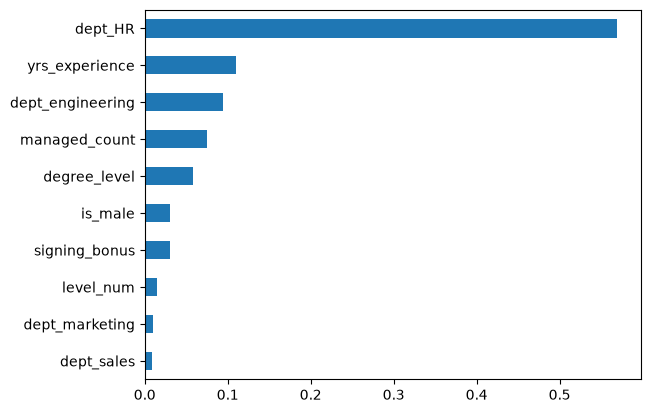

In [41]:
"""
Dept_HR is being impacted the most from output of the model, yrs_exp understandably, ngeering
"""
feat_importances.sort_values().plot(kind='barh')
plt.show()

In [42]:
### Quick cell to check, is_male numbers, Only because speaking of HR, what are the numbers for each gender? ###
print(combined.groupby('dept')['is_male'].mean())
print(combined['is_male'].value_counts())

dept
HR             0.375443
engineering    0.751113
marketing      0.676119
sales          0.671853
Name: is_male, dtype: float64
is_male
1    6438
0    3561
Name: count, dtype: int64


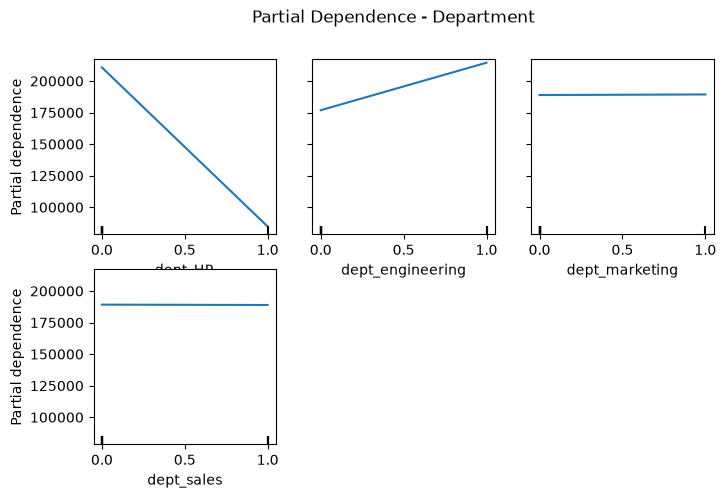

In [43]:
from sklearn.inspection import PartialDependenceDisplay

features = ['dept_HR', 'dept_engineering', 'dept_marketing', 'dept_sales']

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(rf, X_train, features=features, kind="average", ax=ax)
plt.suptitle("Partial Dependence - Department")
plt.show()

In [44]:
from sklearn.inspection import partial_dependence

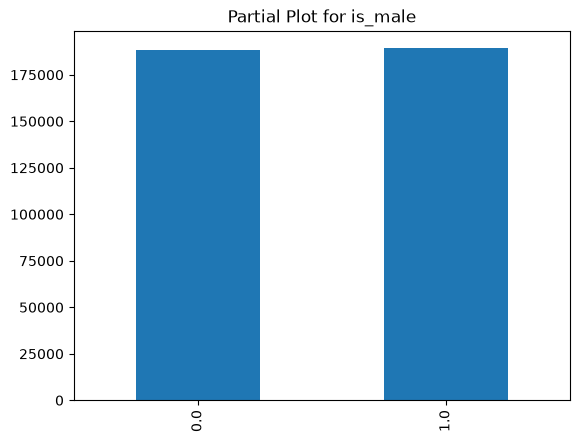

In [45]:
### Gender doesn't seem to be significant factor determining salary ###
X_train_float = X_train.copy()
X_train_float['is_male'] = X_train_float['is_male'].astype(float)

pdp = partial_dependence(rf, X_train_float, ['is_male'])
pdp_dataset = pd.Series(pdp['average'][0], index=pdp['grid_values'][0])
pdp_dataset.plot(kind='bar', title='Partial Plot for is_male')
plt.show()

In [46]:
"""
From the plot above (RandomForestRegressor, partial dependence display) After running the model train/test for both (X/y, salary)
    most noticable is the HR department.  

No direct-pay discrimination, above partial dependence shows both genders both close enough to not be a factor. 
Dept_HR is direct driver of salary, not gender. HR is only 37.5% male while the other 62.5% female.
Would consider/explore women possibly under-represented in higher paying departments.  Going into more detail, hiring pipelines, internal mobility, etc.
"""

'\nFrom the plot above (RandomForestRegressor, partial dependence display) After running the model train/test for both (X/y, salary)\n    most noticable is the HR department.  \n\nNo direct-pay discrimination, above partial dependence shows both genders both close enough to not be a factor. \nDept_HR is direct driver of salary, not gender. HR is only 37.5% male while the other 62.5% female.\nWould consider/explore women possibly under-represented in higher paying departments.  Going into more detail, hiring pipelines, internal mobility, etc.\n'